In [ ]:
# from transformers import AutoModelForVision2Seq, AutoProcessor
from transformers import IdeficsForVisionText2Text, AutoProcessor
from PIL import Image
import torch

import requests

2025-04-27 13:38:39.281952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745761119.297230       9 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745761119.301234       9 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 13:38:39.317355: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# url = "https://i.redd.it/u372z8loi7xe1.jpeg"
url = "https://i.redd.it/vtjpqriz4axe1.png"
# url = "https://i.redd.it/u2smvl331axe1.jpeg"
# url = "https://i.redd.it/vgy37xvi39xe1.jpeg"
# url = "https://i.redd.it/hsny4knu18xe1.png"
# url = "https://i.redd.it/1epklvyd48xe1.jpeg"
# url = "https://media.sproutsocial.com/uploads/meme-example.jpg"
# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
# image = Image.open(image_path).convert('RGB')

In [ ]:
# image.save("./memes/geeks.jpg")

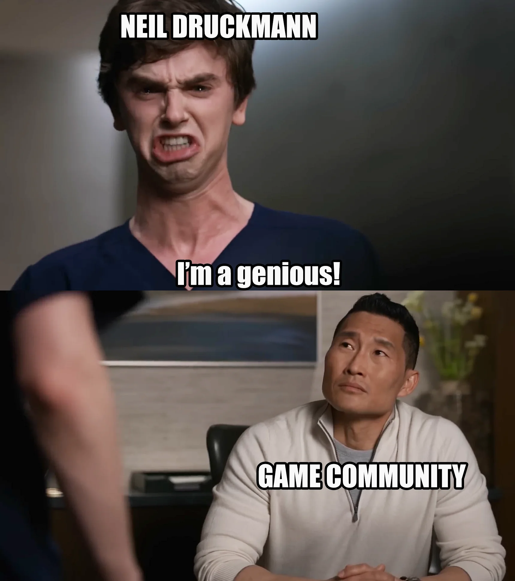

In [3]:
width, height = image.size
percentage = 30  # Example: resize to 50%
new_width = int(width * (percentage / 100))
new_height = int(height * (percentage / 100))
img_resized = image.resize((new_width, new_height))
display(img_resized)

In [ ]:
# Define el modelo
model_name = "HuggingFaceM4/idefics-9b"  # también existe la versión 'idefics-80b'

# Prepara el modelo y el processor
model = IdeficsForVisionText2Text.from_pretrained(model_name, torch_dtype=torch.bfloat16, device_map="auto")
# model = IdeficsForVisionText2Text.from_pretrained(checkpoint, torch_dtype=torch.bfloat16).to(device)
processor = AutoProcessor.from_pretrained(model_name)
# model = AutoModelForVision2Seq.from_pretrained(model_name, torch_dtype=torch.bfloat16, device_map="auto")

Loading checkpoint shards:   0%|          | 0/19 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [27]:
prompts = [
    [
        # "https://upload.wikimedia.org/wikipedia/commons/8/86/Id%C3%A9fix.JPG",
        "https://i.redd.it/vtjpqriz4axe1.png",
        "We can see"
    ],
]


# Preprocesa la entrada
# inputs = processor.apply_chat_template(text=prompt, chat_template=chat_template, return_tensors="pt")
inputs = processor(prompts, return_tensors="pt")
# inputs = inputs.to(device)
# pixel_values = processor(images=image, return_tensors="pt").pixel_values
# pixel_values = pixel_values.to(device)

bad_words_ids = processor.tokenizer(["<image>", "<fake_token_around_image>"], add_special_tokens=False).input_ids

generated_ids = model.generate(**inputs, bad_words_ids=bad_words_ids, max_length=100)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
for i, t in enumerate(generated_text):
    print(f"{i}:\n{t}\n")


# # Genera la respuesta
# with torch.no_grad():
#     outputs = model.generate(
#         input_ids=inputs,
#         pixel_values=pixel_values,
#         max_new_tokens=100,
#         do_sample=False
#     )

# # Decodifica el resultado
# response = processor.batch_decode(outputs, skip_special_tokens=True)[0]

# print(f"\n🔹 Caption generado usando IDEFICS: {response}")

0:
We can see a man wearing a black color shirt and a man wearing a blue color shirt.



# HuggingFaceM4/idefics-9b-instruct

In [1]:
import torch
from transformers import IdeficsForVisionText2Text, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = "HuggingFaceM4/idefics-9b-instruct"
model = IdeficsForVisionText2Text.from_pretrained(checkpoint, torch_dtype=torch.bfloat16).to(device)
# model = IdeficsForVisionText2Text.from_pretrained(checkpoint, torch_dtype=torch.bfloat16)
processor = AutoProcessor.from_pretrained(checkpoint)


2025-04-27 14:08:41.144330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745762921.160016       9 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745762921.164145       9 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 14:08:41.183356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 86.00 MiB. GPU 0 has a total capacity of 11.75 GiB of which 111.62 MiB is free. Process 63610 has 10.80 GiB memory in use. Of the allocated memory 10.56 GiB is allocated by PyTorch, and 146.25 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# We feed to the model an arbitrary sequence of text strings and images. Images can be either URLs or PIL Images.
prompts = [
    [
        "User: What is in this image?",
        "https://upload.wikimedia.org/wikipedia/commons/8/86/Id%C3%A9fix.JPG",
        "<end_of_utterance>",

        "\nAssistant: This picture depicts Idefix, the dog of Obelix in Asterix and Obelix. Idefix is running on the ground.<end_of_utterance>",

        "\nUser:",
        "https://static.wikia.nocookie.net/asterix/images/2/25/R22b.gif/revision/latest?cb=20110815073052",
        "And who is that?<end_of_utterance>",

        "\nAssistant:",
    ],
]

# --batched mode
inputs = processor(prompts, add_end_of_utterance_token=False, return_tensors="pt").to(device)
# inputs = processor(prompts, add_end_of_utterance_token=False, return_tensors="pt")
# --single sample mode
# inputs = processor(prompts[0], return_tensors="pt").to(device)

# Generation args
exit_condition = processor.tokenizer("<end_of_utterance>", add_special_tokens=False).input_ids
bad_words_ids = processor.tokenizer(["<image>", "<fake_token_around_image>"], add_special_tokens=False).input_ids

generated_ids = model.generate(**inputs, eos_token_id=exit_condition, bad_words_ids=bad_words_ids, max_length=100)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
for i, t in enumerate(generated_text):
    print(f"{i}:\n{t}\n")

You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.


0:
User: What is in this image? 
Assistant: This picture depicts Idefix, the dog of Obelix in Asterix and Obelix. Idefix is running on the ground. 
User: And who is that? 
Assistant: That is a cartoon character from the Asterix comics, specifically Obelix.

